In [3]:
data_dir = "/scratch/mjehangir/manuscript_figures/manuscript_data//"

In [4]:
setwd(data_dir)

In [5]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tidyverse)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [6]:
# Read the CSV file into a data frame
#df_cnv <- read.delim("Mean_normalized_v3_tab.seg", header = TRUE)
df_arms <- read.delim("/home/mjehangir/chm13_chrs_arms/cytoBandMapped.bed", header = TRUE)
t2t_telomere = read.csv(file = "chm13v2.0_telomere.bed.txt", header = TRUE, sep = "\t")


In [7]:
#head(df_cnv)
head(df_arms)
head(t2t_telomere)

,chr1,X0,X1735965,p36.33,gneg
,<chr>,<int>,<int>,<chr>,<chr>
1,chr1,1735965,4816989,p36.32,gpos25
2,chr1,4816989,6629068,p36.31,gneg
3,chr1,6629068,8634052,p36.23,gpos25
4,chr1,8634052,12044143,p36.22,gneg
5,chr1,12044143,15341266,p36.21,gpos50
6,chr1,15341266,19923637,p36.13,gneg


,chr,start,end
,<chr>,<int>,<int>
1,chr1,0,3000
2,chr1,248384000,248387328
3,chr2,0,3600
4,chr2,242693800,242696752
5,chr3,0,2800
6,chr3,200904400,200905400


In [8]:
#assign p and q arms to t2t telomeres data
t2t_telomere <- t2t_telomere %>%
  #rename(chrom = V1, telomere_start = V2, telomere_end = V3) %>%
  group_by(chr) %>%
  arrange(start) %>%
  mutate(Arm = case_when(
    row_number() == 1 ~ "p",
    row_number() == n() ~ "q",
    TRUE ~ NA_character_
  )) %>%
  ungroup()
head(t2t_telomere)

chr,start,end,Arm
<chr>,<int>,<int>,<chr>
chr1,0,3000,p
chr2,0,3600,p
chr3,0,2800,p
chr4,0,3400,p
chr5,0,2400,p
chr6,0,3000,p


In [9]:
colnames(df_arms) <- c("chr", "start", "end", "band", "stain")
head(df_arms)

,chr,start,end,band,stain
,<chr>,<int>,<int>,<chr>,<chr>
1,chr1,1735965,4816989,p36.32,gpos25
2,chr1,4816989,6629068,p36.31,gneg
3,chr1,6629068,8634052,p36.23,gpos25
4,chr1,8634052,12044143,p36.22,gneg
5,chr1,12044143,15341266,p36.21,gpos50
6,chr1,15341266,19923637,p36.13,gneg


In [10]:
# Step 2: Create 'arm' column
df_arms <- df_arms %>%
  mutate(arm = ifelse(
    stain == "acen", "centromere",
    ifelse(grepl("^p", band), "p", "q")
  ))

# Step 3: Calculate the size for each row
df_arms <- df_arms %>%
  mutate(size = end - start)

# Step 4: Group by chromosome and arm, and calculate total size, start, and end
df_arms <- df_arms %>%
  group_by(chr, arm) %>%
  summarise(
    total_size = sum(size),
    start = min(start),  # get the first start position for each group
    end = max(end)       # get the last end position for each group
  )

# Step 5: View the results
print(df_arms)

`summarise()` has grouped output by 'chr'. You can override using the `.groups`
argument.


# A tibble: 72 × 5
# Groups:   chr [24]
   chr   arm        total_size     start       end
   <chr> <chr>           <int>     <int>     <int>
 1 chr1  centromere    4504439 121796048 126300487
 2 chr1  p           120060083   1735965 121796048
 3 chr1  q           122086841 126300487 248387328
 4 chr10 centromere    2030796  39633793  41664589
 5 chr10 p            39633793         0  39633793
 6 chr10 q            93093545  41664589 134758134
 7 chr11 centromere    3415049  51035789  54450838
 8 chr11 p            51035789         0  51035789
 9 chr11 q            80676931  54450838 135127769
10 chr12 centromere    2581652  34620838  37202490
# ℹ 62 more rows


In [11]:
# Merge the data
t2t_merged_data <- bind_rows(
  df_arms %>% select(chr, arm, start, end),
  t2t_telomere %>% mutate(arm = paste0(Arm, "_telomere")) %>% select(chr, arm, start, end)
) %>%
  arrange(chr, start)

# View the merged data
head(t2t_merged_data)
write.table(head(t2t_merged_data), file = "/scratch//mjehangir/manuscript_figures/manuscript_data/chm13_tel_cent.txt", sep = "\t", row.names = FALSE, quote = FALSE)


chr,arm,start,end
<chr>,<chr>,<int>,<int>
chr1,p_telomere,0,3000
chr1,p,1735965,121796048
chr1,centromere,121796048,126300487
chr1,q,126300487,248387328
chr1,q_telomere,248384000,248387328
chr10,p,0,39633793


In [12]:
sv_data = read.csv(file = "/home/mjehangir/telomere-sv-analysis/data/severus_somatic_with_pq_arms.txt", sep = '\t', header = TRUE)
head(sv_data)

,chr,start,end,arm_length,type,filename,size,arm
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<chr>
1,chr1,1414067,1415349,124048267,DEL,2436A,1282,p
2,chr1,3010201,3010202,124048267,INS,2436A,3771,p
3,chr1,12524812,12554643,124048267,DEL,2436A,29831,p
4,chr1,16152446,16152447,124048267,INS,2436A,368,p
5,chr1,34498454,34509010,124048267,DEL,2436A,10556,p
6,chr1,35019427,35019801,124048267,DUP,2436A,374,p


In [13]:
# First, fix types for start/end in sv_data_clean
sv_data_clean <- sv_data %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end)
  )

In [14]:
head(sv_data_clean)
head(t2t_merged_data)

,chr,start,end,arm_length,type,filename,size,arm
,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>
1,chr1,1414067,1415349,124048267,DEL,2436A,1282,p
2,chr1,3010201,3010202,124048267,INS,2436A,3771,p
3,chr1,12524812,12554643,124048267,DEL,2436A,29831,p
4,chr1,16152446,16152447,124048267,INS,2436A,368,p
5,chr1,34498454,34509010,124048267,DEL,2436A,10556,p
6,chr1,35019427,35019801,124048267,DUP,2436A,374,p


chr,arm,start,end
<chr>,<chr>,<int>,<int>
chr1,p_telomere,0,3000
chr1,p,1735965,121796048
chr1,centromere,121796048,126300487
chr1,q,126300487,248387328
chr1,q_telomere,248384000,248387328
chr10,p,0,39633793


In [15]:
unique(sv_data_clean$type)

[1] "DEL" "INS" "DUP" "INV" "BND"

In [16]:
# Join separate arm coordinates safely
sv_scaled <- sv_data_clean %>%
  select(-arm) %>%  # remove existing 'arm' column if present
  left_join(
    df_arms %>% filter(arm == "p") %>% select(chr, start_p = start), 
    by = "chr"
  ) %>%
  left_join(
    df_arms %>% filter(arm == "q") %>% select(chr, end_q = end), 
    by = "chr"
  ) %>%
  left_join(
    df_arms %>% filter(arm == "centromere") %>% select(chr, centromere_start = start), 
    by = "chr"
  ) %>%
  mutate(
    midpoint = (start + end) / 2,
    scaled_pos = (midpoint - start_p) / (end_q - start_p),
    centromere_pos = if_else(
      !is.na(centromere_start) & !is.na(start_p) & !is.na(end_q),
      (centromere_start - start_p) / (end_q - start_p),
      NA_real_
    )
  ) %>%
  filter(!is.na(scaled_pos))

In [17]:
head(sv_scaled)

,chr,start,end,arm_length,type,filename,size,start_p,end_q,centromere_start,midpoint,scaled_pos,centromere_pos
,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,chr1,1414067,1415349,124048267,DEL,2436A,1282,1735965,248387328,121796048,1414708,-0.001302474,0.4867603
2,chr1,3010201,3010202,124048267,INS,2436A,3771,1735965,248387328,121796048,3010202,0.005166144,0.4867603
3,chr1,12524812,12554643,124048267,DEL,2436A,29831,1735965,248387328,121796048,12539728,0.043801755,0.4867603
4,chr1,16152446,16152447,124048267,INS,2436A,368,1735965,248387328,121796048,16152446,0.058448822,0.4867603
5,chr1,34498454,34509010,124048267,DEL,2436A,10556,1735965,248387328,121796048,34503732,0.132850541,0.4867603
6,chr1,35019427,35019801,124048267,DUP,2436A,374,1735965,248387328,121796048,35019614,0.134942084,0.4867603


In [18]:
head(sv_data_clean)


,chr,start,end,arm_length,type,filename,size,arm
,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>
1,chr1,1414067,1415349,124048267,DEL,2436A,1282,p
2,chr1,3010201,3010202,124048267,INS,2436A,3771,p
3,chr1,12524812,12554643,124048267,DEL,2436A,29831,p
4,chr1,16152446,16152447,124048267,INS,2436A,368,p
5,chr1,34498454,34509010,124048267,DEL,2436A,10556,p
6,chr1,35019427,35019801,124048267,DUP,2436A,374,p


In [19]:
options(repr.plot.width = 30, repr.plot.height = 10, repr.plot.res = 200)



In [20]:
telomeres <- t2t_merged_data %>% 
  filter(arm %in% c("p_telomere", "q_telomere"))

centromeres <- t2t_merged_data %>% 
  filter(arm == "centromere")


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


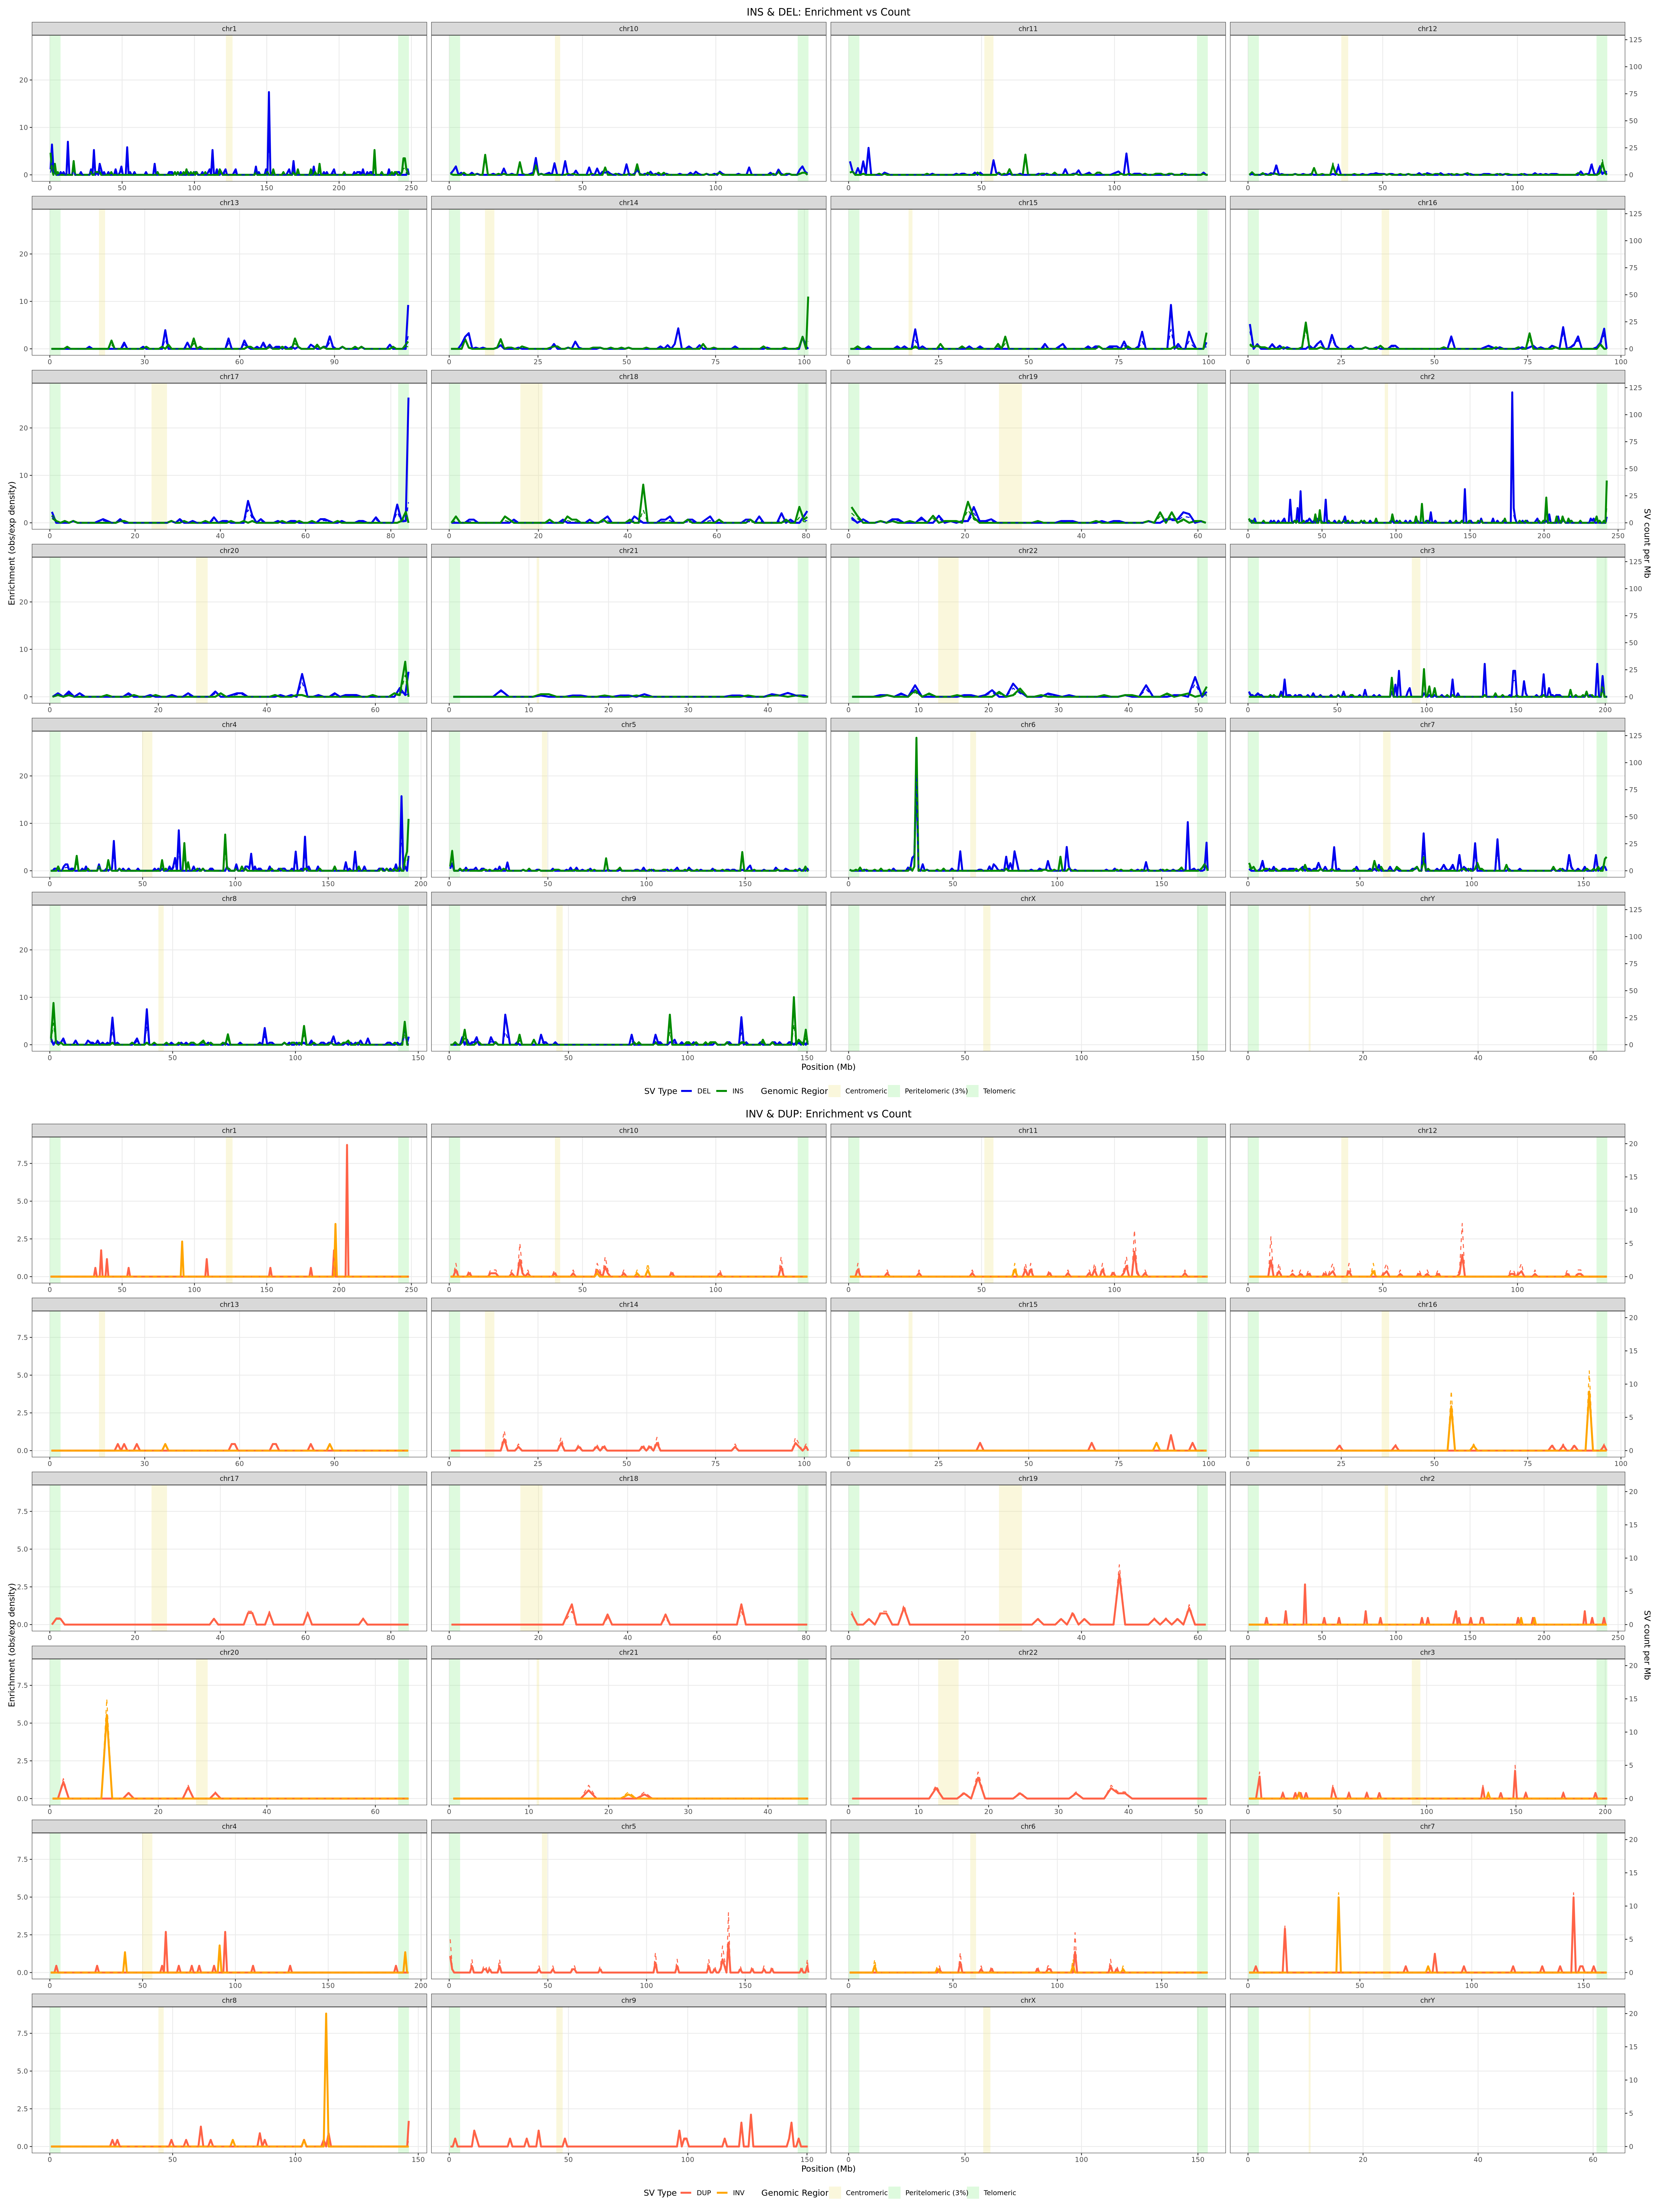

In [21]:


#─── Parameters ───────────────────────────────────────────────────────────────
bin_size     <- 1e6      # 1 Mb bins
peritel_pct  <- 0.03     # 3% of chromosome length at each end
chromosomes  <- paste0("chr", 1:22)

#─── 1) Compute chromosome lengths ────────────────────────────────────────────
chr_lengths <- t2t_merged_data %>%
  group_by(chr) %>%
  summarise(chr_len = max(end), .groups = "drop")

#─── 2) Define peritelomeric (3%) windows ────────────────────────────────────
peritelomeric_pct <- chr_lengths %>%
  mutate(
    p_start = 0,
    p_end   = chr_len * peritel_pct,
    q_start = chr_len * (1 - peritel_pct),
    q_end   = chr_len
  ) %>%
  pivot_longer(
    cols         = c(p_start:p_end, q_start:q_end),
    names_to     = c("arm","bound"),
    names_pattern= "(.+)_(.+)",
    values_to    = "coord"
  ) %>%
  pivot_wider(
    names_from  = bound,
    values_from = coord
  ) %>%
  mutate(highlight_type = "Peritelomeric (3%)") %>%
  select(chr, arm, start, end, highlight_type)

#─── 3) Extract telomeres & centromeres ───────────────────────────────────────
telomeres <- t2t_merged_data %>%
  filter(arm %in% c("p_telomere","q_telomere")) %>%
  mutate(highlight_type = "Telomeric") %>%
  select(chr, arm, start, end, highlight_type)

centromeres <- t2t_merged_data %>%
  filter(arm == "centromere") %>%
  mutate(highlight_type = "Centromeric") %>%
  select(chr, arm, start, end, highlight_type)

#─── 4) Combine all highlight regions ─────────────────────────────────────────
highlight_regions <- bind_rows(telomeres, peritelomeric_pct, centromeres)

#─── 5) Function to bin SVs & compute enrichment ──────────────────────────────
process_chromosome <- function(chr) {
  sv_chr  <- sv_data_clean   %>% filter(chr == !!chr)
  seg_chr <- t2t_merged_data %>% filter(chr == !!chr)
  chr_len <- max(seg_chr$end, na.rm = TRUE)
  
  bins_chr <- tibble(
    bin   = 1:ceiling(chr_len / bin_size),
    start = (bin - 1) * bin_size,
    end   = pmin(bin * bin_size, chr_len)
  )
  
  counts_chr <- sv_chr %>%
    mutate(bin = floor(start / bin_size) + 1) %>%
    filter(bin <= nrow(bins_chr)) %>%
    count(type, bin) %>%
    complete(type = unique(sv_chr$type), bin = 1:nrow(bins_chr), fill = list(n = 0)) %>%
    rename(count = n) %>%
    left_join(bins_chr, by = "bin") %>%
    mutate(
      density    = count / (end - start),
      enrichment = density / (nrow(sv_chr) / chr_len),
      midpos_mb  = (start + end) / (2e6),
      chr        = chr
    )
  
  counts_chr %>% filter(type != "BND")
}

#─── 6) Compute for all chromosomes ────────────────────────────────────────────
all_counts <- map_df(chromosomes, process_chromosome)

#─── 7) Plotting function with dual axes & highlights ─────────────────────────
plot_dual_allchr <- function(df, regions, types, cols, title) {
  sub <- df %>% filter(type %in% types)
  sf  <- max(sub$count, na.rm = TRUE) / max(sub$enrichment, na.rm = TRUE)

    
  options(repr.plot.width = 30, repr.plot.height = 40, repr.plot.res = 200)

  ggplot() +
    geom_rect(
      data = regions,
      aes(
        xmin = start / 1e6,
        xmax = end   / 1e6,
        ymin = -Inf,
        ymax = Inf,
        fill = highlight_type
      ),
      alpha = 0.3
    ) +
    geom_line(
      data = sub,
      aes(x = midpos_mb, y = enrichment, color = type),
      size = 1.2
    ) +
    geom_line(
      data = sub,
      aes(x = midpos_mb, y = count / sf, color = type),
      size = 0.6,
      linetype = "dashed"
    ) +
    scale_y_continuous(
      name    = "Enrichment (obs/exp density)",
      sec.axis= sec_axis(~ . * sf, name = "SV count per Mb")
    ) +
    scale_fill_manual(
      values = c(
        "Telomeric"            = "lightgreen",
        "Peritelomeric (3%)"   = "lightgreen",
        "Centromeric"          = "khaki"
      ),
      name = "Genomic Region"
    ) +
    scale_color_manual(values = cols) +
    labs(x = "Position (Mb)", title = title, color = "SV Type") +
    facet_wrap(~chr, scales = "free_x", ncol = 4) +
    theme_bw() +
    theme(
      legend.position   = "bottom",
      panel.grid.minor  = element_blank(),
      plot.title        = element_text(hjust = 0.5)
    )
}

#─── 8) Generate the two plots ─────────────────────────────────────────────────
cols_ins_del <- c(INS = "green4", DEL = "blue2")
cols_inv_dup <- c(INV = "orange", DUP = "tomato")

p1 <- plot_dual_allchr(
  all_counts, highlight_regions,
  types = c("INS","DEL"), cols = cols_ins_del,
  title = "INS & DEL: Enrichment vs Count"
)

p2 <- plot_dual_allchr(
  all_counts, highlight_regions,
  types = c("INV","DUP"), cols = cols_inv_dup,
  title = "INV & DUP: Enrichment vs Count"
)

#─── 9) Arrange vertically ────────────────────────────────────────────────────
p1 / p2



In [22]:
library(ggplot2)
library(patchwork)

# Create the combined plot
combined_plot <- p1 / p2

# Save as PDF
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig5/severus_combined_lineplots.pdf", combined_plot, width = 25, height = 40)

In [39]:
head(all_counts)

type,bin,count,start,end,density,enrichment,midpos_mb,chr,midpos_bp
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
DEL,1,543,0e+00,1e+06,0.000543,3.128464,0.5,chr1,500000
DEL,2,398,1e+06,2e+06,0.000398,2.293054,1.5,chr1,1500000
DEL,3,1290,2e+06,3e+06,0.001290,7.432261,2.5,chr1,2500000
DEL,4,402,3e+06,4e+06,0.000402,2.316100,3.5,chr1,3500000
DEL,5,255,4e+06,5e+06,0.000255,1.469168,4.5,chr1,4500000
DEL,6,202,5e+06,6e+06,0.000202,1.163811,5.5,chr1,5500000
